In [1]:
from pathlib import Path
import importlib
import sys

workspace_root = Path.cwd().parent.parent
sys.path.insert(0, str(workspace_root))

import experiments.plots.shacl_violation_distribution as shacl_violation_distribution

shacl_violation_distribution = importlib.reload(shacl_violation_distribution)

run_directory = workspace_root / "results" / "royalty_gemini_with_shacl"
violations_by_message = shacl_violation_distribution.collect_non_class_violations_by_task(str(run_directory))

# Filter for class disjointness violations (case-insensitive search)
class_disjointness_tasks = set()
for message, tasks in violations_by_message.items():
    if "disjoint" in message.lower():
        class_disjointness_tasks.update(tasks)

# Filter for max count violations
max_count_tasks = set()
for message, tasks in violations_by_message.items():
    if "More than" in message:
        max_count_tasks.update(tasks)

print(f"Number of different tasks with class disjointness violations: {len(class_disjointness_tasks)}")
print(f"Number of different tasks with max count violations: {len(max_count_tasks)}")

Number of different tasks with class disjointness violations: 3
Number of different tasks with max count violations: 19


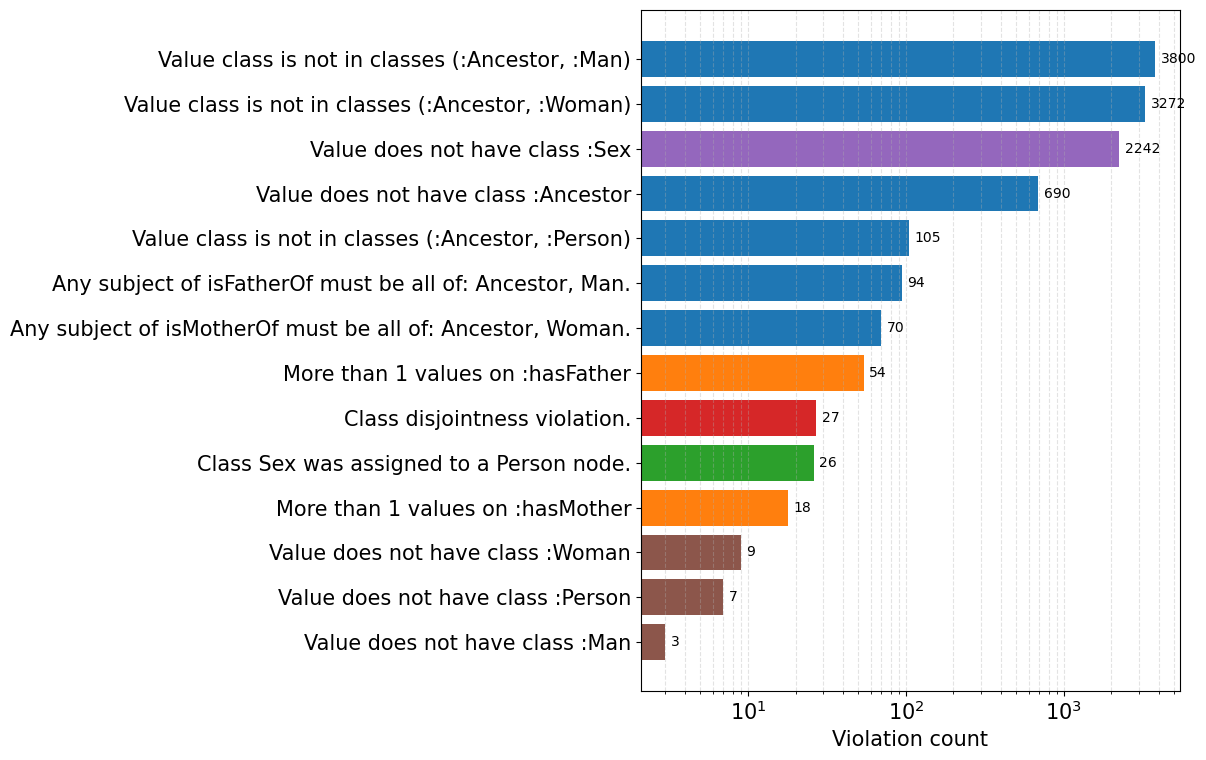

In [2]:
from pathlib import Path
import importlib
import sys
from collections import Counter
from textwrap import shorten

import matplotlib.pyplot as plt

workspace_root = Path.cwd().parent.parent
sys.path.insert(0, str(workspace_root))

import experiments.plots.shacl_violation_distribution as shacl_violation_distribution

shacl_violation_distribution = importlib.reload(shacl_violation_distribution)

run_directory = workspace_root / "results" / "royalty_gemini_with_shacl"
class_message_counts = shacl_violation_distribution.collect_class_constraint_messages(str(run_directory))
non_class_message_counts = shacl_violation_distribution.collect_non_class_constraint_messages(str(run_directory))
reorganized_non_class_counts = shacl_violation_distribution.reorganize_non_class_violations(non_class_message_counts)
combined_message_counts = Counter(class_message_counts) + Counter(reorganized_non_class_counts)

if not combined_message_counts:
    print("No SHACL violations found.")
else:
    ordered_items = combined_message_counts.most_common()
    label_overrides = {
        "Node is closed": "Class Sex was assigned to a Person node.",
    }
    labels = [shorten(label_overrides.get(label, label), width=90, placeholder="...") for label, _ in ordered_items]
    values = [value for _, value in ordered_items]

    ancestor_bar_positions = {1, 2, 4, 5, 6, 7}
    more_than_bar_positions = {8, 11}
    distinct_bar_colors = {
        3: "#9467bd",
        9: "#d62728",
        10: "#2ca02c",
        12: "#8c564b",
        13: "#8c564b",
        14: "#8c564b",
    }
    ancestor_color = "#1f77b4"
    more_than_color = "#ff7f0e"
    bar_colors = []

    for index, label in enumerate(labels, start=1):
        if index in ancestor_bar_positions:
            bar_colors.append(ancestor_color)
        elif index in more_than_bar_positions:
            bar_colors.append(more_than_color)
        else:
            bar_colors.append(distinct_bar_colors.get(index, "#7f7f7f"))

    fig, ax = plt.subplots(figsize=(12, max(4.0, 0.55 * len(labels))))
    bars = ax.barh(labels, values, color=bar_colors)
    ax.set_xlabel("Violation count", fontsize=15)
    ax.set_xscale("log")
    ax.invert_yaxis()
    ax.grid(axis="x", linestyle="--", alpha=0.35, which="both")
    ax.tick_params(axis="both", labelsize=15)

    for bar in bars:
        width = bar.get_width()
        ax.annotate(
            f"{int(width)}",
            (width, bar.get_y() + bar.get_height() / 2),
            ha="left",
            va="center",
            fontsize=10,
            xytext=(4, 0),
            textcoords="offset points",
        )

    output_pdf = workspace_root / "results" / "royalty_gemini_with_shacl" / "combined_message_groups.pdf"
    fig.savefig(output_pdf, format="pdf", bbox_inches="tight")
    plt.tight_layout()
    plt.show()

In [3]:
from collections import Counter
from pathlib import Path
import importlib
import json
import sys

from rdflib import Graph, SH, RDF

workspace_root = Path.cwd().parent.parent.parent
sys.path.insert(0, str(workspace_root))

import experiments.plots.shacl_violation_distribution as shacl_violation_distribution

shacl_violation_distribution = importlib.reload(shacl_violation_distribution)

run_directory = workspace_root / "results" / "royalty_gemini_with_shacl"
closed_violations = Counter()

for graphs_path in sorted(run_directory.rglob("artifacts/graphs.json")):
    try:
        records = json.loads(graphs_path.read_text(encoding="utf-8"))
    except (OSError, json.JSONDecodeError):
        continue

    if not isinstance(records, list):
        continue

    for record in records:
        if not isinstance(record, dict):
            continue

        if record.get("graph_type") != "validation_graph":
            continue

        graph_text = record.get("graph")
        if not isinstance(graph_text, str):
            continue

        try:
            graph = Graph()
            graph.parse(data=graph_text, format="turtle")
        except Exception:
            continue

        for result_node in graph.subjects(RDF.type, SH.ValidationResult):
            message = graph.value(result_node, SH.resultMessage)
            path = graph.value(result_node, SH.resultPath)
            component = graph.value(result_node, SH.sourceConstraintComponent)

            if component != SH.ClosedConstraintComponent:
                continue

            if message is None:
                continue

            closed_violations[(str(message), str(path) if path is not None else "(no path)")] += 1

if not closed_violations:
    print("No Node is closed violations found.")
else:
    print("Node is closed violations with path component:")
    for (message, path), count in closed_violations.most_common():
        print(f"- {count}x {message} | path: {path}")
    print(f"Total combined into Node is closed: {sum(closed_violations.values())}")

No Node is closed violations found.


5 (run, shape, doc) combination(s) had no inferred graph and were excluded from the count:
  ('royalty_gemini_without_shacl', 'F1_typing', 372)
  ('royalty_gemini_without_shacl', 'F2_cardinality', 372)
  ('royalty_gemini_without_shacl', 'F3_class_disjointness', 372)
  ('royalty_gemini_without_shacl', 'F4_property_disjointness', 372)
  ('royalty_gemini_without_shacl', 'F5_closed_shapes', 372)


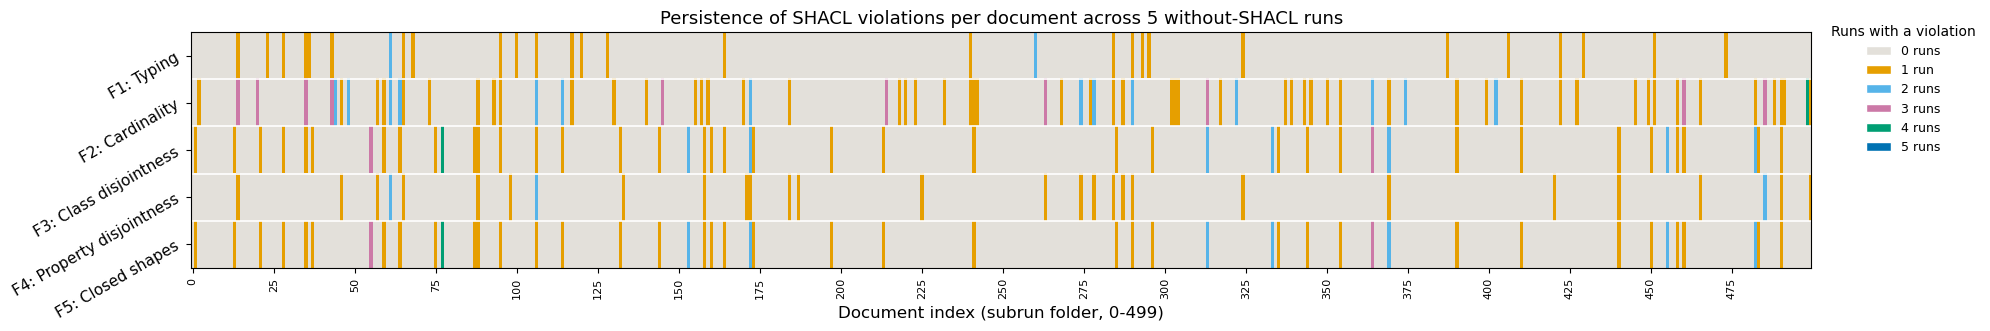

In [4]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch

workspace_root = Path.cwd().parent.parent
reports_dir = workspace_root / "helpers" / "validation_reports" / "f_shapes_without_shacl"

run_names = [
    "royalty_gemini_without_shacl",
    "royalty_gemini_without_shacl_1",
    "royalty_gemini_without_shacl_2",
    "royalty_gemini_without_shacl_3",
    "royalty_gemini_without_shacl_4",
]

shape_families = [
    ("F1_typing", "F1: Typing"),
    ("F2_cardinality", "F2: Cardinality"),
    ("F3_class_disjointness", "F3: Class disjointness"),
    ("F4_property_disjointness", "F4: Property disjointness"),
    ("F5_closed_shapes", "F5: Closed shapes"),
]

num_docs = 500
fired_counts = np.zeros((len(shape_families), num_docs), dtype=int)
missing_cells = []

for run_name in run_names:
    run_report = json.loads((reports_dir / f"{run_name}.json").read_text(encoding="utf-8"))
    for doc_index in range(num_docs):
        doc_result = run_report.get(str(doc_index))
        if doc_result is None:
            continue
        for row, (shape_key, _) in enumerate(shape_families):
            conforms = doc_result.get(shape_key, {}).get("conforms")
            if conforms is None:
                missing_cells.append((run_name, shape_key, doc_index))
            elif conforms is False:
                fired_counts[row, doc_index] += 1

if missing_cells:
    print(f"{len(missing_cells)} (run, shape, doc) combination(s) had no inferred graph and were excluded from the count:")
    for item in missing_cells:
        print(f"  {item}")

# Highly distinct, CVD-checked categorical colors per level (0 = never fired
# through 5 = fired in every run) instead of shades of a single hue -- with
# 2500 densely packed cells, gradations of one color are hard to tell apart
# at a glance, so each count gets its own hue (Okabe-Ito derived; validated
# all-pairs distinguishable under simulated color-vision deficiency).
level_colors = ["#e3e0da", "#E69F00", "#56B4E9", "#CC79A7", "#009E73", "#0072B2"]
level_labels = ["0", "1", "2", "3", "4", "5"]
cmap = ListedColormap(level_colors)
norm = BoundaryNorm(np.arange(-0.5, 6.5, 1), cmap.N)

fig, ax = plt.subplots(figsize=(20, 3.4))
im = ax.imshow(fired_counts, aspect="auto", cmap=cmap, norm=norm, interpolation="none")

ax.set_yticks(range(len(shape_families)))
# Skewed labels take up less horizontal margin than horizontal text, leaving
# more of the figure width for the heatmap itself.
ax.set_yticklabels([label for _, label in shape_families], fontsize=11, rotation=30, ha="right")
ax.set_xlabel("Document index (subrun folder, 0-499)", fontsize=12)
ax.set_xticks(range(0, num_docs, 25))
ax.set_xticklabels(range(0, num_docs, 25), fontsize=8, rotation=90)
ax.set_xlim(-0.5, num_docs - 0.5)

for y in np.arange(0.5, len(shape_families) - 0.5, 1):
    ax.axhline(y, color="white", linewidth=1.2)

legend_handles = [
    Patch(facecolor=color, edgecolor="white", label=f"{label} run{'' if label == '1' else 's'}")
    for color, label in zip(level_colors, level_labels)
]
ax.legend(
    handles=legend_handles,
    title="Runs with a violation",
    loc="upper left",
    bbox_to_anchor=(1.005, 1.08),
    fontsize=9,
    title_fontsize=10,
    frameon=False,
)

ax.set_title(
    "Persistence of SHACL violations per document across 5 without-SHACL runs",
    fontsize=13,
)

fig.tight_layout()
output_pdf = workspace_root / "results" / "f_shapes_violation_persistence.pdf"
fig.savefig(output_pdf, format="pdf", bbox_inches="tight")
plt.show()


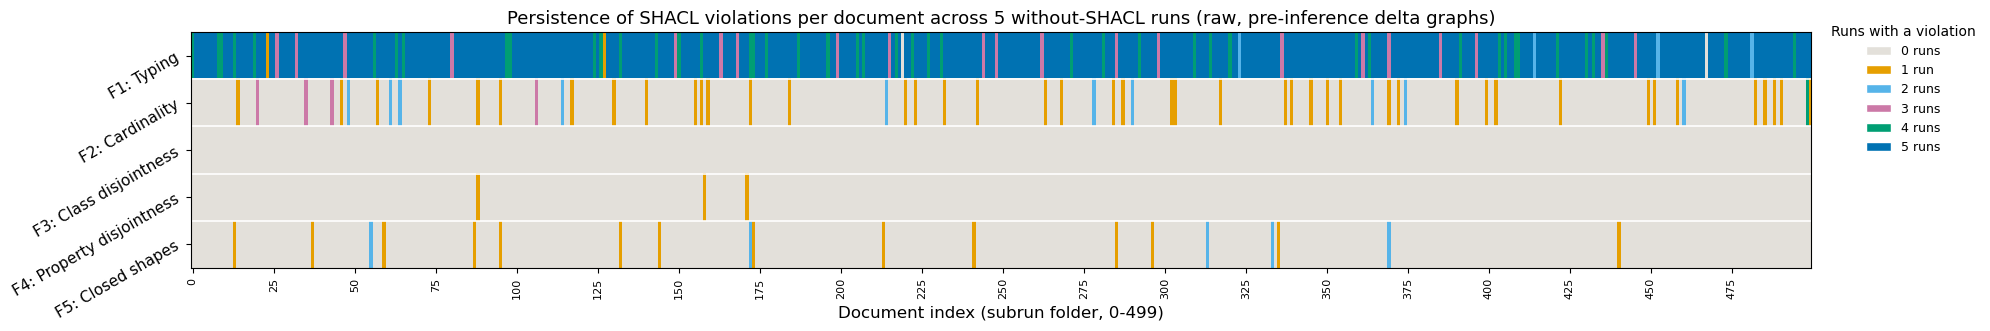

In [5]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch

workspace_root = Path.cwd().parent.parent
reports_dir = workspace_root / "helpers" / "validation_reports" / "f_shapes_without_shacl_raw"

run_names = [
    "royalty_gemini_without_shacl",
    "royalty_gemini_without_shacl_1",
    "royalty_gemini_without_shacl_2",
    "royalty_gemini_without_shacl_3",
    "royalty_gemini_without_shacl_4",
]

shape_families = [
    ("F1_typing", "F1: Typing"),
    ("F2_cardinality", "F2: Cardinality"),
    ("F3_class_disjointness", "F3: Class disjointness"),
    ("F4_property_disjointness", "F4: Property disjointness"),
    ("F5_closed_shapes", "F5: Closed shapes"),
]

num_docs = 500
fired_counts = np.zeros((len(shape_families), num_docs), dtype=int)
missing_cells = []

for run_name in run_names:
    run_report = json.loads((reports_dir / f"{run_name}.json").read_text(encoding="utf-8"))
    for doc_index in range(num_docs):
        doc_result = run_report.get(str(doc_index))
        if doc_result is None:
            continue
        for row, (shape_key, _) in enumerate(shape_families):
            conforms = doc_result.get(shape_key, {}).get("conforms")
            if conforms is None:
                missing_cells.append((run_name, shape_key, doc_index))
            elif conforms is False:
                fired_counts[row, doc_index] += 1

if missing_cells:
    print(f"{len(missing_cells)} (run, shape, doc) combination(s) had no delta graph and were excluded from the count:")
    for item in missing_cells:
        print(f"  {item}")

# Same distinct, CVD-checked categorical colors and layout as the inferred-graph
# heatmap above, applied here to the raw (pre-inference) delta_graph.ttl siblings.
level_colors = ["#e3e0da", "#E69F00", "#56B4E9", "#CC79A7", "#009E73", "#0072B2"]
level_labels = ["0", "1", "2", "3", "4", "5"]
cmap = ListedColormap(level_colors)
norm = BoundaryNorm(np.arange(-0.5, 6.5, 1), cmap.N)

fig, ax = plt.subplots(figsize=(20, 3.4))
im = ax.imshow(fired_counts, aspect="auto", cmap=cmap, norm=norm, interpolation="none")

ax.set_yticks(range(len(shape_families)))
ax.set_yticklabels([label for _, label in shape_families], fontsize=11, rotation=30, ha="right")
ax.set_xlabel("Document index (subrun folder, 0-499)", fontsize=12)
ax.set_xticks(range(0, num_docs, 25))
ax.set_xticklabels(range(0, num_docs, 25), fontsize=8, rotation=90)
ax.set_xlim(-0.5, num_docs - 0.5)

for y in np.arange(0.5, len(shape_families) - 0.5, 1):
    ax.axhline(y, color="white", linewidth=1.2)

legend_handles = [
    Patch(facecolor=color, edgecolor="white", label=f"{label} run{'' if label == '1' else 's'}")
    for color, label in zip(level_colors, level_labels)
]
ax.legend(
    handles=legend_handles,
    title="Runs with a violation",
    loc="upper left",
    bbox_to_anchor=(1.005, 1.08),
    fontsize=9,
    title_fontsize=10,
    frameon=False,
)

ax.set_title(
    "Persistence of SHACL violations per document across 5 without-SHACL runs (raw, pre-inference delta graphs)",
    fontsize=13,
)

fig.tight_layout()
output_pdf = workspace_root / "results" / "f_shapes_violation_persistence_raw.pdf"
fig.savefig(output_pdf, format="pdf", bbox_inches="tight")
plt.show()
